In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

df = pd.read_csv("FPI-1-11-26.csv")

dfs = {}

for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_{year}.csv")

Mean 2015 0.0031250000000000444
SD 2015 4.958894542198409
Mean 2016 2.220446049250313e-16
SD 2016 4.51613594469517
Mean 2017 0.0031250000000000444
SD 2017 5.135297483294953
Mean 2018 -0.0031249999999999334
SD 2018 5.511833859978002
Mean 2019 0.0
SD 2019 5.968519565725793
Mean 2020 -0.0031250000000000444
SD 2020 5.175156807660128
Mean 2021 0.0031249999999999334
SD 2021 4.959349877723634
Mean 2022 -0.0031249999999998224
SD 2022 7.758096057376697
Mean 2023 0.0062500000000002
SD 2023 5.2517239872930945
Mean 2024 -0.16874999999999996
SD 2024 4.467620966104241


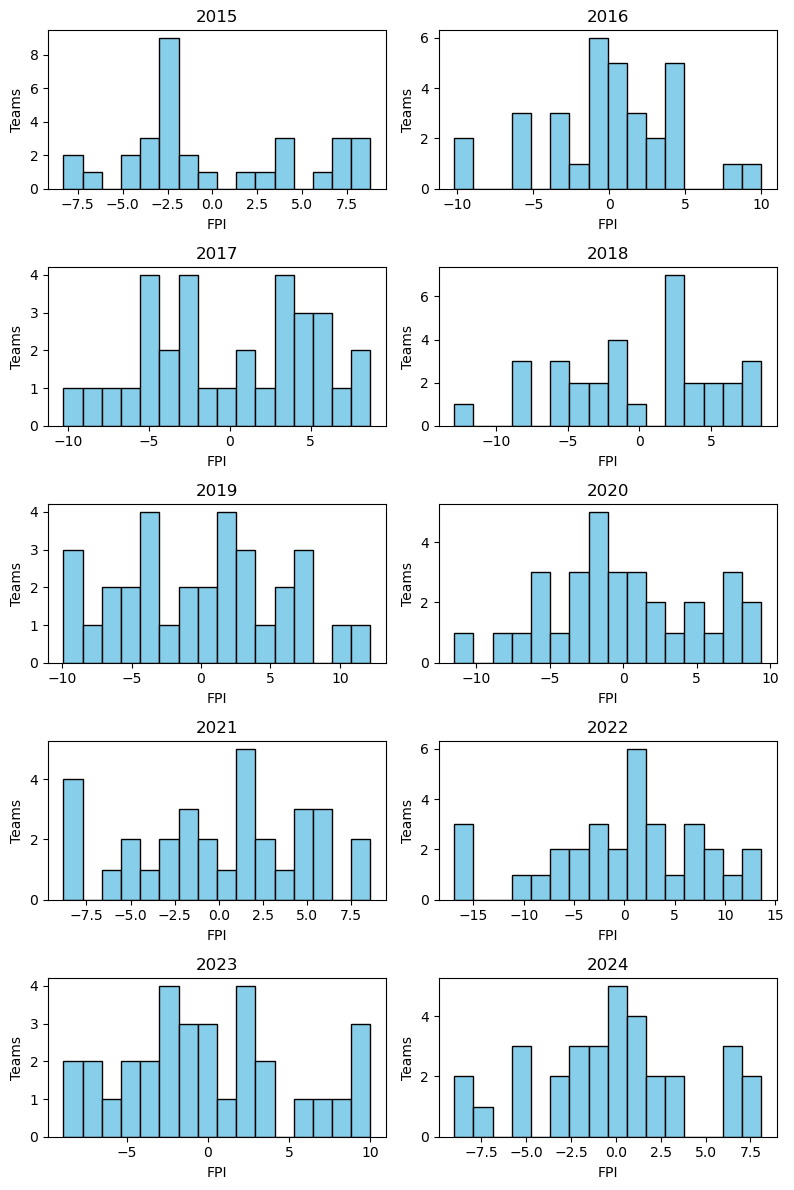

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(8, 12))
axes = axes.flatten()

for i, year in enumerate(range(2015, 2025)):
    ax = axes[i]
    ax.hist(dfs[year]["FPI"], bins=16, edgecolor="black", color = "skyblue")
    ax.set_title(f"{year}")
    ax.set_xlabel("FPI")
    ax.set_ylabel("Teams")
    print("Mean", year, (dfs[year]["FPI"]).mean())
    print("SD", year, (dfs[year]["FPI"]).std())

plt.tight_layout()
plt.show()

5.367759174738909

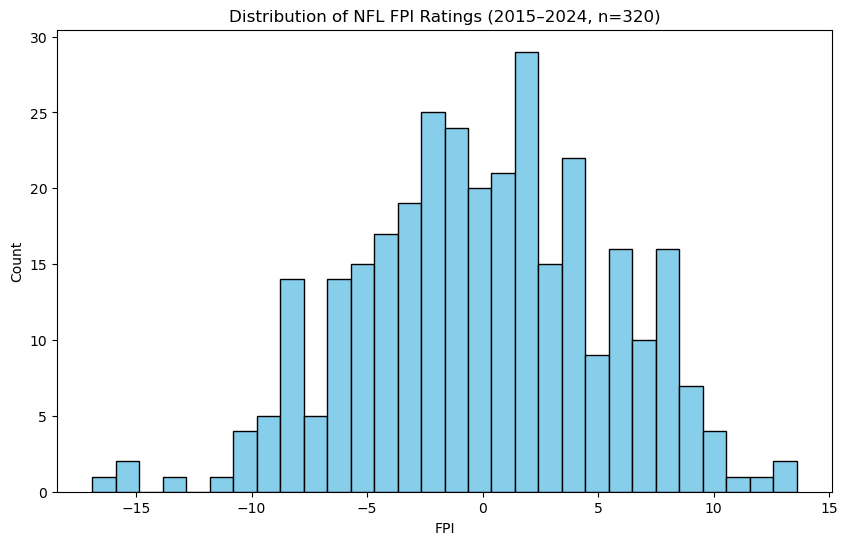

In [14]:
# Combine all FPI values into one Series
fpi_all = pd.concat([dfs[year]["FPI"] for year in range(2015, 2025)])

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(fpi_all, bins=30, edgecolor="black", color = "skyblue")
plt.title("Distribution of NFL FPI Ratings (2015–2024, n=320)")
plt.xlabel("FPI")
plt.ylabel("Count")

fpi_all.mean()
fpi_all.std()

In [15]:
def simulate_game(power1: float, power2: float, sigma: float, home_field: float, rng):
    margin = (power1 - power2) + home_field + (sigma * rng.normal(0, 1))  # sigma2 = home advantage constant
    win1 = margin > 0
    return margin, win1

def build_divisional_schedule(division_teams):
    schedule = [] # This will store all games as (Home, Away)

    # For every pair of teams in the division
    for div_teams in division_teams.values():
        for a, b in combinations(div_teams, 2): 
            schedule.append((a, b)) # a home
            schedule.append((b, a)) # b home
    return schedule

#Example
#print(build_divisional_schedule({"NFC North": division_teams["NFC North"]}))

# Pairing up divisions for schedule 
def pair_up(divs,seed):
    rng = np.random.default_rng(seed) #Random number
    divs = list(divs) #List out all divisions
    rng.shuffle(divs) # Shuffle the divisions
    pairs = []

    for i in range(0, len(divs), 2): # Loop through the list two elements at a time
        pair = (divs[i], divs[i+1]) # Pair current division with the next one
        pairs.append(pair)

    return pairs
    
#Example
#print(pair_up(afc_divs,1))
#print(pair_up(nfc_divs,5))

def two_random_conference_games(df, schedule, pairs, seed=1):
    rng = np.random.default_rng(seed)

    division_teams = df.groupby("Division")["Team"].apply(list).to_dict()

    (A, B) = pairs[0] # The first pair that was selected
    (C, D) = pairs[1] # The second pair that was selected

    division_1 = division_teams[A][:] # Teams from each division
    division_2 = division_teams[B][:]
    division_3 = division_teams[C][:]
    division_4 = division_teams[D][:]

    rng.shuffle(division_1) # Shuffle all divisions
    rng.shuffle(division_2)
    rng.shuffle(division_3)
    rng.shuffle(division_4)

    for i in range(4):
        a = division_1[i]
        b = division_2[i]
        c = division_3[i]
        d = division_4[i]

        # Pair up 1 team from a with a team from division c and d
        schedule.append((a, c)) 
        schedule.append((d, a))

        # Pair up 1 team from b with a team from division c and d
        schedule.append((b, d))
        schedule.append((c, b))

    return schedule


def division_vs_division(df, schedule, d1, d2,seed):
    rng = np.random.default_rng(seed)  # Random number

    division_teams = df.groupby("Division")["Team"].apply(list).to_dict()
    nfc_divs = [d for d in division_teams if d.split()[0] == "NFC"]
    afc_divs = [d for d in division_teams if d.split()[0] == "AFC"]

    A = division_teams[d1]  # Division 1
    B = division_teams[d2] # Division 2

    # Shuffling B for random home and away assignments
    B_perm = B[:] # Make a copy of B
    rng.shuffle(B_perm) # Shuffle the teams in B, this makes it so home/away assignments aren't the same every time

    for i in range(4): # Loop through every team in division A
        a = A[i] # a = Current team in division A

        # These two teams will be hosted by team a
        home1 = B_perm[i] 
        home2 = B_perm[(i + 1)%4] # % 4 allows wrapping around if index reaches the end
        # So let's say Packers are team 4 in division a, they'd host team 4 and team 1 in division b
        # Loop through every team in division B
        for b in B:
            if b == home1 or b == home2:
                schedule.append((a, b))  # Team a is home vs team b
            else:
                schedule.append((b, a))  # Team b is home vs team a

# Example
# print(division_vs_division(build_divisional_schedule({"NFC North": division_teams["NFC North"]})))

In [16]:
def generate_schedule(df: pd.DataFrame, seed: int = 1):

    rng = np.random.default_rng(seed)
    
    division_teams = df.groupby("Division")["Team"].apply(list).to_dict()
    nfc_divs = [d for d in division_teams if d.split()[0] == "NFC"]
    afc_divs = [d for d in division_teams if d.split()[0] == "AFC"]

    schedule = build_divisional_schedule(division_teams)
    
    # Divisional Schedule
    schedule = build_divisional_schedule(division_teams)

    # Pair up divisions
    nfc_pairs = pair_up(nfc_divs, seed)  # 2 pairs
    afc_pairs = pair_up(afc_divs, seed)  # 2 pairs
    
    # NFC Division matchups
    for d1, d2 in nfc_pairs:
        division_vs_division(df,schedule, d1, d2, seed)

    # AFC Division matchups
    for d1, d2 in afc_pairs:
        division_vs_division(df,schedule, d1, d2, seed)

    # NFC vs AFC matchup
    afc_shuf = afc_divs[:]  # Make a copy of AFC divisions
    rng.shuffle(afc_shuf) # Shuffle AFC divisions
    cross_pairs = list(zip(nfc_divs, afc_shuf))  # pairs up every division with each other

    for d1, d2 in cross_pairs:
        division_vs_division(df,schedule, d1, d2, seed)

    schedule = two_random_conference_games(df, schedule, nfc_pairs, seed=seed + 100)
    schedule = two_random_conference_games(df, schedule, afc_pairs, seed=seed + 200)

    # converts schedule into a data frame
    schedule_df = pd.DataFrame(schedule, columns=["Home", "Away"])

    return schedule_df

#Example:
#schedule_df = generate_schedule(df, seed=4)

#print(schedule_df[(schedule_df["Home"] == "New England Patriots") |
                  #(schedule_df["Away"] == "New England Patriots")])

In [17]:
def simulate_season(df, schedule_df, sigma=9, home_field=2, seed=1):
    rng = np.random.default_rng(seed)
    n_games = 16

    teams = df["Team"].tolist() # All 32 NFL teams
    power = dict(zip(df["Team"], df["FPI"])) # Pairs teams with their assigned rating

    # -Simulate all games -----------------------------------
    results = []  # Will store every game's results

    for _, row in schedule_df.iterrows(): # The _, is to ignore the index
        home = row["Home"]
        away = row["Away"]

        # Simulate the game
        margin, home_wins = simulate_game(power1= power[home], power2= power[away],sigma=sigma,home_field=home_field,rng = rng)

        # Store the result
        if home_wins:
            winner = home
            loser = away
        else:
            winner = away
            loser = home

        results.append({"Home": home,"Away": away,"Winner": winner,"Loser": loser})

    results_df = pd.DataFrame(results)
    
    # Count the wins ---------------------------------------
    wins = {}

    # Start every team out with 0 wins
    for team in teams:
        wins[team] = 0

    # Count wins from results
    for winner in results_df["Winner"]:
        wins[winner] += 1
    
    # Standings ---------------------------------------------
    standings = []

    for team in teams:
        standings.append({"Team": team,"Wins": wins[team], "Losses": n_games - wins[team], "FPI": power[team],})

    standings_df = pd.DataFrame(standings)

    # Sort standings by wins (descending) -------------------
    standings_df = standings_df.sort_values(by="Wins", ascending=False).reset_index(drop=True)
    
    #Creating the "FPI vs True difference" -------------------
    standings_df["Final_Rank"] = standings_df.index + 1
    fpi_ranks = (df.sort_values("FPI", ascending=False).reset_index(drop=True))
    fpi_ranks["FPI_Rank"] = fpi_ranks.index + 1

    standings_df = standings_df.merge(fpi_ranks[["Team", "FPI_Rank"]],on="Team",how="left")

    standings_df["FPI vs True difference"] = (standings_df["FPI_Rank"] - standings_df["Final_Rank"])
    #standings_df.drop(columns=["Final_Rank", "FPI_Rank"], inplace=True)
    return results_df, standings_df

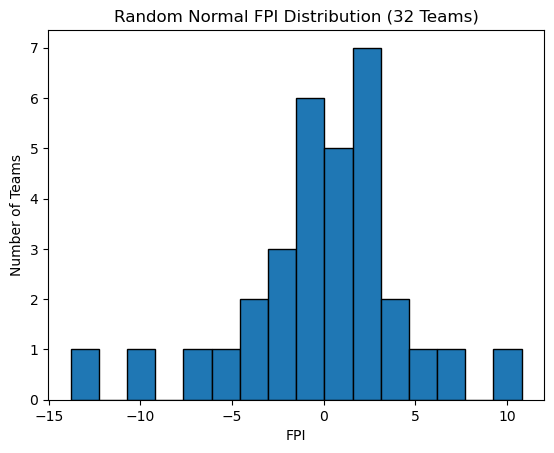

                     Team  Wins  Losses   FPI  Final_Rank  FPI_Rank  \
0          Miami Dolphins    16       0  10.8           1         1   
1         Atlanta Falcons    14       2   5.1           2         3   
2     San Francisco 49ers    12       4   1.9           3        10   
3    Jacksonville Jaguars    11       5   1.5           4        13   
4           Detroit Lions    11       5   1.7           5        12   
5       Minnesota Vikings    10       6  -0.9           6        20   
6        Seattle Seahawks    10       6   4.2           7         5   
7           New York Jets    10       6   1.1           8        14   
8          Houston Texans    10       6   3.0           9         7   
9      New Orleans Saints     9       7   6.6          10         2   
10     Cincinatti Bengals     9       7  -0.8          11        19   
11    Pittsburgh Steelers     9       7   0.2          12        16   
12   New England Patriots     9       7   2.8          13         8   
13    

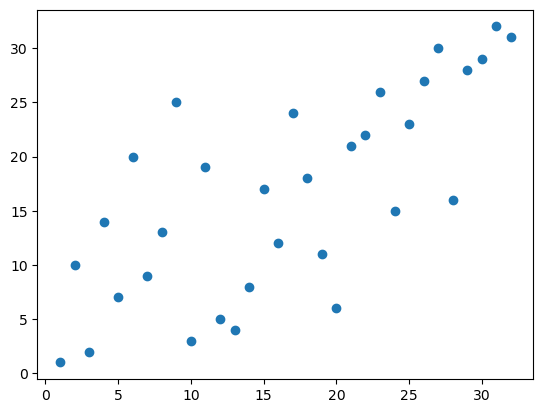

In [18]:
def make_random_fpi(df, mean=0.003, std=5.1, seed=1):
    rng = np.random.default_rng(seed)
    df_rand = df.copy()

    # Create 32 random FPI values from a normal distribution
    df_rand["FPI"] = rng.normal(loc=mean, scale=std, size=len(df_rand))
    df_rand["FPI"] = round(df_rand["FPI"],1)
    return df_rand

df_rand = make_random_fpi(df, mean=0.003, std=5.1,seed = 1)
plt.hist(df_rand["FPI"], bins=16, edgecolor="black")
plt.title("Random Normal FPI Distribution (32 Teams)")
plt.xlabel("FPI")
plt.ylabel("Number of Teams")
plt.show()

schedule_df = generate_schedule(df_rand, seed=1)
results_df, standings_df = simulate_season(df_rand, schedule_df, sigma=9, home_field=2, seed=6)

print(standings_df.head(32))
plt.scatter(standings_df["FPI_Rank"],standings_df["Final_Rank"])